In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATASET_CSV_PATH = "../data/CICIoT2023/ciciot2023_labeled_conn.tsv"
# DATASET_CSV_PATH = "../data/CICIDS2017/wednesday_labeled.tsv"

Device: cuda


In [3]:
df = pd.read_csv(DATASET_CSV_PATH, delimiter="\t", on_bad_lines="skip")
print(df.shape)
df.head()


(1850844, 23)


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label
0,1.665163e+09,CktBip1sFHNchgO7kb,192.168.137.41,50093,157.249.81.141,443,tcp,-,0.126077,251,...,F,0,ADF,4,459,0,0,-,6,BENIGN
1,1.665163e+09,CuckeIVEEpWRUL51i,192.168.137.172,41150,52.207.44.110,80,tcp,-,4.780317,0,...,F,0,F,2,104,0,0,-,6,BENIGN
2,1.665163e+09,Cgk4rv3Zok2KZiyHij,192.168.137.41,51746,157.249.81.141,80,tcp,http,0.291959,196,...,F,376,SADhgFadf,5,464,5,643,-,6,BENIGN
3,1.665163e+09,CVpJpI3GzZ18oGjoCf,192.168.137.41,50096,157.249.81.141,443,tcp,ssl,0.291320,251,...,F,8,SADhgFadf,5,519,5,275,-,6,BENIGN
4,1.665163e+09,CnUiCh2UbvrkCSKyDa,192.168.137.41,51749,157.249.81.141,80,tcp,http,0.292739,196,...,F,376,SADhgFadf,5,464,5,643,-,6,BENIGN


In [4]:
FEATURES = ["proto", "conn_state", "duration", "orig_bytes", "resp_bytes", "orig_pkts", "resp_pkts"]

def normalize_label(label):
    return str(label).strip().replace("-", "_").replace(" ", "_").replace("/", "_").upper()

def preprocess_data(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df.drop_duplicates(inplace=True)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df = df[FEATURES + ["label"]].copy()
    df["label"] = df["label"].map(normalize_label)
    df.dropna(inplace=True)
    return df

cleaned_df = preprocess_data(df)
print(cleaned_df.shape)
print(cleaned_df["label"].value_counts())

(1850844, 8)
label
DOS_HTTP_FLOOD    1508589
BENIGN             342255
Name: count, dtype: int64


In [5]:
cleaned_df = cleaned_df[cleaned_df["label"].isin(["BENIGN", "DOS_HTTP_FLOOD"])].copy()
print(cleaned_df["label"].value_counts())

label
DOS_HTTP_FLOOD    1508589
BENIGN             342255
Name: count, dtype: int64


In [6]:
X = cleaned_df[FEATURES]
y = cleaned_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42,
)

print("Train label distribution (before balancing):")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Train label distribution (before balancing):
label
DOS_HTTP_FLOOD    1056012
BENIGN             239578
Name: count, dtype: int64

Test label distribution:
label
DOS_HTTP_FLOOD    452577
BENIGN            102677
Name: count, dtype: int64


In [7]:
def balance_dataset(X, y, random_state=42):
    label_col="label"
    df = X.copy()
    df[label_col] = y.values

    counts = df[label_col].value_counts()
    min_count = counts.min()

    balanced_parts = []
    for label in counts.index:
        sampled = df[df[label_col] == label].sample(n=min_count, random_state=random_state)
        balanced_parts.append(sampled)

    balanced_df = (
        pd.concat(balanced_parts, ignore_index=True)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

    X_bal = balanced_df.drop(columns=[label_col])
    y_bal = balanced_df[label_col]
    return X_bal, y_bal

In [8]:
X_train_balanced, y_train_balanced = balance_dataset(X_train, y_train)

print(y_train_balanced.value_counts())

label
BENIGN            239578
DOS_HTTP_FLOOD    239578
Name: count, dtype: int64


In [9]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_balanced)
y_test_enc = label_encoder.transform(y_test)

# Encode categorical features
X_train_balanced = X_train_balanced.copy()
X_test = X_test.copy()

categorical_cols = X_train_balanced.select_dtypes(include=["str"]).columns
ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_balanced[categorical_cols] = ordinal_encoder.fit_transform(X_train_balanced[categorical_cols])
X_test[categorical_cols] = ordinal_encoder.transform(X_test[categorical_cols])

print("Categorical columns:", list(categorical_cols))
X_train_balanced.head()

Categorical columns: ['proto', 'conn_state', 'duration', 'orig_bytes', 'resp_bytes']


,proto,conn_state,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts
0,1.0,10.0,134669.0,12660.0,2124.0,14,13
1,2.0,6.0,0.0,0.0,0.0,1,0
2,2.0,6.0,0.0,0.0,0.0,1,0
3,2.0,6.0,282165.0,12455.0,1.0,2,0
4,1.0,2.0,278675.0,9192.0,495.0,9,6


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced[FEATURES])
X_test_scaled = scaler.transform(X_test[FEATURES])

print("Classes:", label_encoder.classes_)

Classes: ['BENIGN' 'DOS_HTTP_FLOOD']


In [19]:
# CNNLSTM expects input shape: (N, 1, F)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

# BCEWithLogitsLoss expects float targets 0/1
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([479156, 1, 7]) torch.Size([479156])
torch.Size([555254, 1, 7]) torch.Size([555254])


In [23]:
class CNNLSTM(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
        )

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.conv(x)          # (N, 128, L)
        x = x.permute(0, 2, 1)    # (N, L, 128)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        logits = self.head(last).squeeze(1)   # (N,)
        return logits

model = CNNLSTM(n_features=len(FEATURES)).to(device)
print(model)

CNNLSTM(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (head): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [24]:
feat_idx = {col: i for i, col in enumerate(FEATURES)}

orig_bytes_idx = feat_idx["orig_bytes"]
orig_pkts_idx = feat_idx["orig_pkts"]

# DOS_HTTP_FLOOD should map to class 1 if label_encoder.classes_ is ['BENIGN', 'DOS_HTTP_FLOOD']
dos_idx = np.where(label_encoder.classes_ == "DOS_HTTP_FLOOD")[0][0]
print("DOS class index:", dos_idx)

theta_orig_bytes = 100.0
theta_orig_pkts = 2.0

orig_bytes_thr_scaled = (theta_orig_bytes - scaler.mean_[orig_bytes_idx]) / scaler.scale_[orig_bytes_idx]
orig_pkts_thr_scaled = (theta_orig_pkts - scaler.mean_[orig_pkts_idx]) / scaler.scale_[orig_pkts_idx]

def soft_leq(x, threshold, sharpness=10.0):
    return torch.sigmoid(sharpness * (threshold - x))

def property_loss(model, x):
    # x shape: (N, 1, F)
    logits = model(x)                 # (N,)
    p_dos = torch.sigmoid(logits)     # probability of DOS_HTTP_FLOOD

    x_flat = x[:, 0, :]               # back to (N, F) for feature access

    low_bytes = soft_leq(x_flat[:, orig_bytes_idx], orig_bytes_thr_scaled)
    low_pkts = soft_leq(x_flat[:, orig_pkts_idx], orig_pkts_thr_scaled)

    antecedent = torch.minimum(low_bytes, low_pkts)

    loss = torch.mean(antecedent * (1.0 - p_dos))

    stats = {
        "low_bytes": low_bytes.mean().item(),
        "low_pkts": low_pkts.mean().item(),
        "antecedent": antecedent.mean().item(),
        "p_dos": p_dos.mean().item(),
    }

    return loss, stats

DOS class index: 1


In [25]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

lambda_prop = 0.5
num_epochs = 10

for epoch in range(num_epochs):
    model.train()

    pred_losses = []
    prop_losses = []

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)          # (N, 1, F)
        y_batch = y_batch.to(device)          # (N,)

        optimizer.zero_grad()

        logits = model(x_batch)               # (N,)
        pred_loss = criterion(logits, y_batch)

        prop_loss, stats = property_loss(model, x_batch)

        loss = pred_loss + lambda_prop * prop_loss
        loss.backward()
        optimizer.step()

        pred_losses.append(pred_loss.item())
        prop_losses.append(prop_loss.item())

    print(
        f"Epoch {epoch+1:02d} | "
        f"pred_loss={np.mean(pred_losses):.4f} | "
        f"prop_loss={np.mean(prop_losses):.4f}"
    )
    print(stats)

Epoch 01 | pred_loss=0.1053 | prop_loss=0.0476
{'low_bytes': 0.2729833126068115, 'low_pkts': 0.48799440264701843, 'antecedent': 0.24982842803001404, 'p_dos': 0.4889800250530243}
Epoch 02 | pred_loss=0.0926 | prop_loss=0.0467
{'low_bytes': 0.31738007068634033, 'low_pkts': 0.4915850758552551, 'antecedent': 0.29126283526420593, 'p_dos': 0.4921277165412903}
Epoch 03 | pred_loss=0.0898 | prop_loss=0.0467
{'low_bytes': 0.29694345593452454, 'low_pkts': 0.49257373809814453, 'antecedent': 0.2727397680282593, 'p_dos': 0.48704788088798523}
Epoch 04 | pred_loss=0.0877 | prop_loss=0.0467
{'low_bytes': 0.28504642844200134, 'low_pkts': 0.49348345398902893, 'antecedent': 0.2618113160133362, 'p_dos': 0.48396727442741394}
Epoch 05 | pred_loss=0.0859 | prop_loss=0.0467
{'low_bytes': 0.28448939323425293, 'low_pkts': 0.49393230676651, 'antecedent': 0.2611861526966095, 'p_dos': 0.5086231827735901}
Epoch 06 | pred_loss=0.0837 | prop_loss=0.0468
{'low_bytes': 0.27073246240615845, 'low_pkts': 0.490673005580902

In [27]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        logits = model(x_batch)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long().cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(y_batch.numpy().astype(int))

y_true_labels = label_encoder.inverse_transform(np.array(all_true))
y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

print(classification_report(y_true_labels, y_pred_labels, digits=4))

                precision    recall  f1-score   support

        BENIGN     0.7898    0.9665    0.8693    102677
DOS_HTTP_FLOOD     0.9920    0.9416    0.9662    452577

      accuracy                         0.9462    555254
     macro avg     0.8909    0.9541    0.9177    555254
  weighted avg     0.9546    0.9462    0.9482    555254



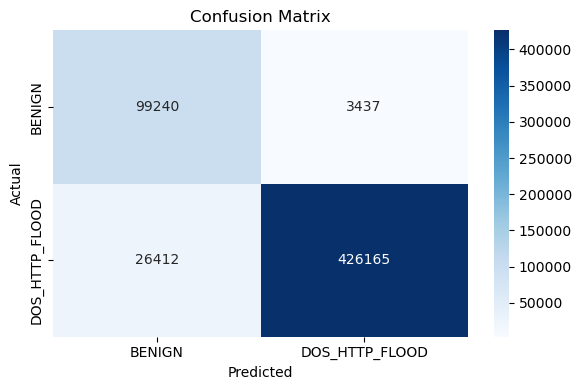

In [28]:
labels = np.unique(np.concatenate([y_true_labels, y_pred_labels]))
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [29]:
model.eval()

prop_losses = []
all_stats = []

with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)
        prop_loss, stats = property_loss(model, x_batch)
        prop_losses.append(prop_loss.item())
        all_stats.append(stats)

print("Average property loss:", np.mean(prop_losses))
print("Last batch stats:", all_stats[-1])

Average property loss: 0.020422400620253155
Last batch stats: {'low_bytes': 0.4291657507419586, 'low_pkts': 0.49596044421195984, 'antecedent': 0.3897307217121124, 'p_dos': 0.7847263813018799}


In [30]:
import os
import joblib

os.makedirs("models", exist_ok=True)

save_path = f"models/cnnlstm_property_{Path(DATASET_CSV_PATH).stem}.joblib"

joblib.dump(
    {
        "model": model.cpu(),
        "ordinal_encoder": ordinal_encoder,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "features": FEATURES,
        "categorical_cols": categorical_cols,
    },
    save_path,
)

print("Saved to:", save_path)
print("Saved encoder n_features_in_:", ordinal_encoder.n_features_in_)

Saved to: models/cnnlstm_property_ciciot2023_labeled_conn.joblib
Saved encoder n_features_in_: 5
